Exploration des données et statistiques

In [ ]:
#imports 
from SPARQLWrapper import SPARQLWrapper
from SPARQLWrapper import JSON, CSV
import matplotlib.pyplot as plt
from SPARQLWrapper import TURTLE
from rdflib import Graph
from rdflib.plugins.sparql.results.jsonresults import JSONResult
from rdflib import Graph, Literal, Namespace, URIRef
from utils import show_graph
from utils import save_graph_html
import os
import importlib
import utils 
importlib.reload(utils)
import time
import networkx as nx
import csv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import seaborn as sns
import json
import squarify
import matplotlib.patches as mpatches
import unicodedata
import re
import itertools

In [ ]:
#sparql endpoint
endpoint = SPARQLWrapper(" ")
endpoint.setReturnFormat(JSON)

#requete sparql
query_date_intervalle = """
               PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
                PREFIX rico: <https://www.ica.org/standards/RiC/ontology#>
                SELECT  ?s ?nomagent ?debut ?fin ?typeAgent
                where{
                ?s a rico:Record;
                    rico:hasCreationDate ?date.
                    ?date rico:beginningDate ?debut;
                        rico:endDate ?fin.
                ?rel rico:relationHasSource ?s .  
                ?rel rico:relationHasTarget ?agent .
                ?rel rico:withCreationRole ?role .
                ?role skos:prefLabel ?typeAgent .
                ?agent rico:name ?nomagent .
                }
                ORDER BY DESC (?fin)

                    """

In [ ]:
endpoint.setQuery(query_date_intervalle)
endpoint.setReturnFormat(CSV)
resultats_csv = endpoint.queryAndConvert()
#bytesIO permet de lire les bytes comme du csv
df = pd.read_csv(io.BytesIO(resultats_csv))

df.head()

,s,nomagent,debut,fin,typeAgent
0,http://rdf.geohistoricaldata.org/id/museeCarna...,Anonyme,1882,2088,Dessinateur
1,http://rdf.geohistoricaldata.org/id/museeCarna...,Imprimerie Charles Lévy (Paris),1882,2088,Imprimeur
2,http://rdf.geohistoricaldata.org/id/museeCarna...,FOLIES-BERGERE,1882,2088,Commanditaire
3,http://rdf.geohistoricaldata.org/id/museeCarna...,FOLIES BERGERE,1882,2088,Commanditaire
4,http://rdf.geohistoricaldata.org/id/museeCarna...,Folies-Bergère,1882,2088,Commanditaire


In [ ]:
#Nettoyage des dateS
def clean_date_to_year(value):
        # On convertit en string pour manipuler uniformément
        val_str = str(value).strip()
        
        if not val_str or val_str.lower() == 'nan':
            return None # Sera géré par safe_int plus tard (ex: 1800)

        # Cas 1 : C'est déjà une année seule (4 chiffres exactement)
        if len(val_str) == 4 and val_str.isdigit():
            return int(val_str)
        
        # Cas 2 : C'est une date longue (ex: 1848-06-28)
        try:
            # pd.to_datetime est intelligent et extraira l'année
            return pd.to_datetime(val_str, errors='coerce').year
        except:
            return None

In [23]:
def assign_epochs(debut, fin):
    epochs = []
    if pd.isna(debut):
        return epochs
    if pd.isna(fin):
        return epochs
    if debut <= 1853 and fin >=1845:
        epochs.append('1845-1853')
    if debut <= 1872 and fin >=1854:
        epochs.append('1854-1872')
    if debut <= 1913 and fin >=1873:
        epochs.append('1873-1913')
    if debut <= 1919 and fin >=1911:
        epochs.append('1911-1919')
    return epochs


# Application de la fonction et duplication des lignes si une affiche/agent chevauche plusieurs époques
df_exploded = df.copy()
df_exploded['epoque'] = df_exploded.apply(
    lambda row: assign_epochs(row['debut'], row['fin']), axis=1)
df_exploded = df_exploded.explode('epoque')

# Suppression des éventuelles lignes hors des époques cibles
df_filtered = df_exploded.dropna(subset=['epoque'])

# Génération du tableau résumé (nombre d'agents uniques et nombre d'affiches uniques 's' par époque)
summary_table = df_filtered.groupby('epoque').agg(
    nombre_agents=('nomagent', 'nunique'),
    nombre_affiches=('s', 'nunique')
).reset_index()

# Réorganisation optionnelle pour respecter l'ordre chronologique des époques
epoch_order = ['1845-1853', '1854-1872', '1873-1913', '1911-1919']
summary_table['epoque'] = pd.Categorical(summary_table['epoque'], categories=epoch_order, ordered=True)
summary_table = summary_table.sort_values('epoque').reset_index(drop=True)

print(summary_table)

      epoque  nombre_agents  nombre_affiches
0  1845-1853            736              379
1  1854-1872           2270             1043
2  1873-1913           6250             2829
3  1911-1919            887              626


In [26]:
#nbre d'affiches
df['s'].nunique()

6856

In [8]:
 # Application du nettoyage
df['debut'] = df['debut'].apply(clean_date_to_year)
df['fin'] = df['fin'].apply(clean_date_to_year)

In [ ]:
cat_file = r" "

#on transforme le contenu en liste
df_cat = pd.read_csv(cat_file)
surtype_affiches = df_cat.groupby('categorie')['valeur'].apply(list).to_dict()


print(surtype_affiches)

{'Administration': ['Affiche administrative', 'Affiche administrative (avis municipal)', "Affiche administrative d'avis public", "Affiche administrative d'information", "Affiche administrative d'information publique", "Affiche administrative d'ordonnance", 'Affiche administrative de consigne de sécurité', 'Affiche administrative de distribution', 'Affiche administrative de distribution de bois', 'Affiche administrative de distribution de charbon', 'Affiche administrative de défense militaire', 'Affiche administrative de guerre', 'Affiche administrative de la Commune', 'Affiche administrative de municipalité', 'Affiche administrative de rationnement', 'Affiche administrative de santé publique', 'Affiche administrative de service public', 'Affiche administrative de vente', 'Affiche administrative et agricole', 'Affiche administrative et artistique', 'Affiche administrative et caritative', 'Affiche administrative et commerciale', 'Affiche administrative et commémorative', 'Affiche adminis

In [ ]:
# 1. Création du dictionnaire de correspondance : variation -> categorie
map_type_vers_cat = {}
for categorie, variations in surtype_affiches.items():
    for var in variations:
        map_type_vers_cat[var] = categorie

# 2. Parcours du dossier de fichiers JSON pour extraire (id URI, categorie)
json_folder = " "
correspondances = []

# Préfixe de l'URI d'origine
uri_prefix = "http://rdf.geohistoricaldata.org/id/museeCarnavalet/ephemeres/record/"

for fichier in os.listdir(json_folder):
    if fichier.endswith('.json'):
        file_path = os.path.join(json_folder, fichier)
        
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
            # Extraction du code (ex: 'CARAFF00946') et reconstruction de l'URI exacte
            id_code = fichier.replace('.json', '') 
            uri_complete = uri_prefix + id_code
            
            type_affiche = data.get('type_affiche')
            
            # Recherche de la catégorie correspondante
            cat_trouvee = map_type_vers_cat.get(type_affiche, None)
            
            correspondances.append({
                's': uri_complete,
                'categorie': cat_trouvee
            })

# 3. Conversion en DataFrame et fusion avec le DataFrame d'origine
df_categories = pd.DataFrame(correspondances)

# Fusion (merge) sur l'URI exacte contenue dans 's'
df = df.merge(df_categories, on='s', how='left')

# Visualisation des résultats
print(df[['s', 'nomagent', 'categorie']].head())

                                                   s  \
0  http://rdf.geohistoricaldata.org/id/museeCarna...   
1  http://rdf.geohistoricaldata.org/id/museeCarna...   
2  http://rdf.geohistoricaldata.org/id/museeCarna...   
3  http://rdf.geohistoricaldata.org/id/museeCarna...   
4  http://rdf.geohistoricaldata.org/id/museeCarna...   

                          nomagent  categorie  
0                          Anonyme  Publicité  
1  Imprimerie Charles Lévy (Paris)  Publicité  
2                   FOLIES-BERGERE  Publicité  
3                   FOLIES BERGERE  Publicité  
4                   Folies-Bergère  Publicité  


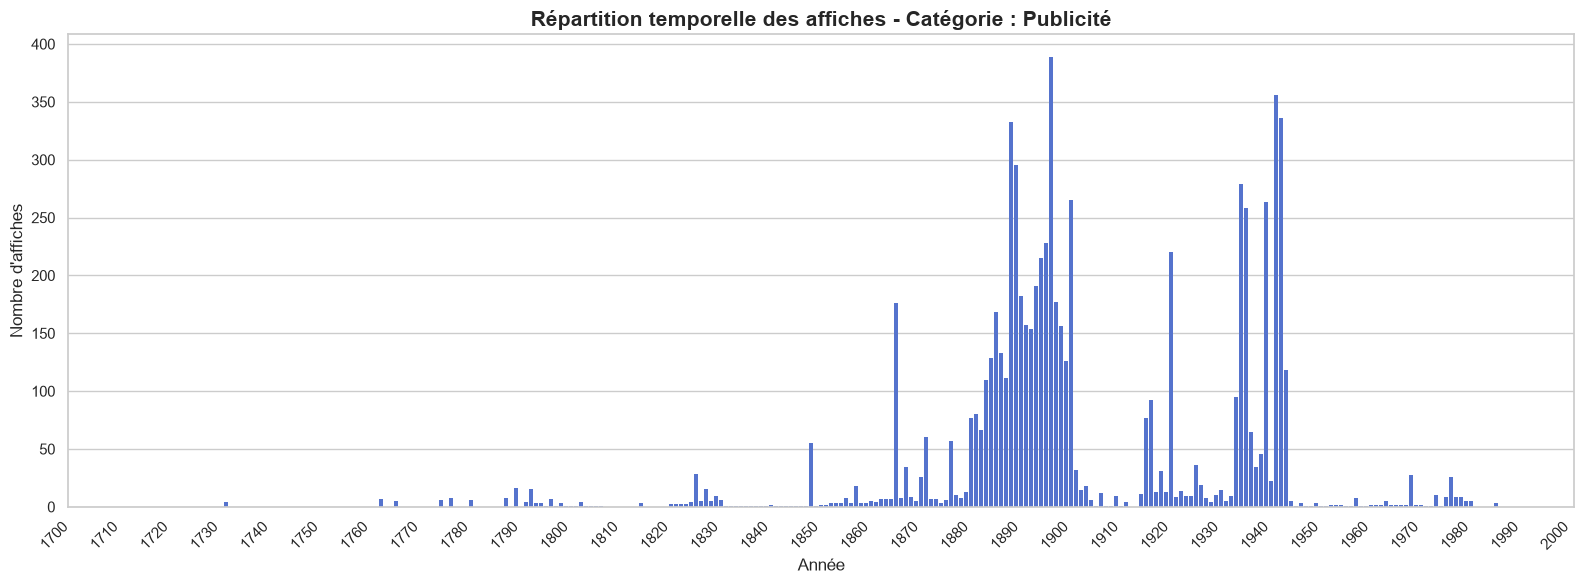

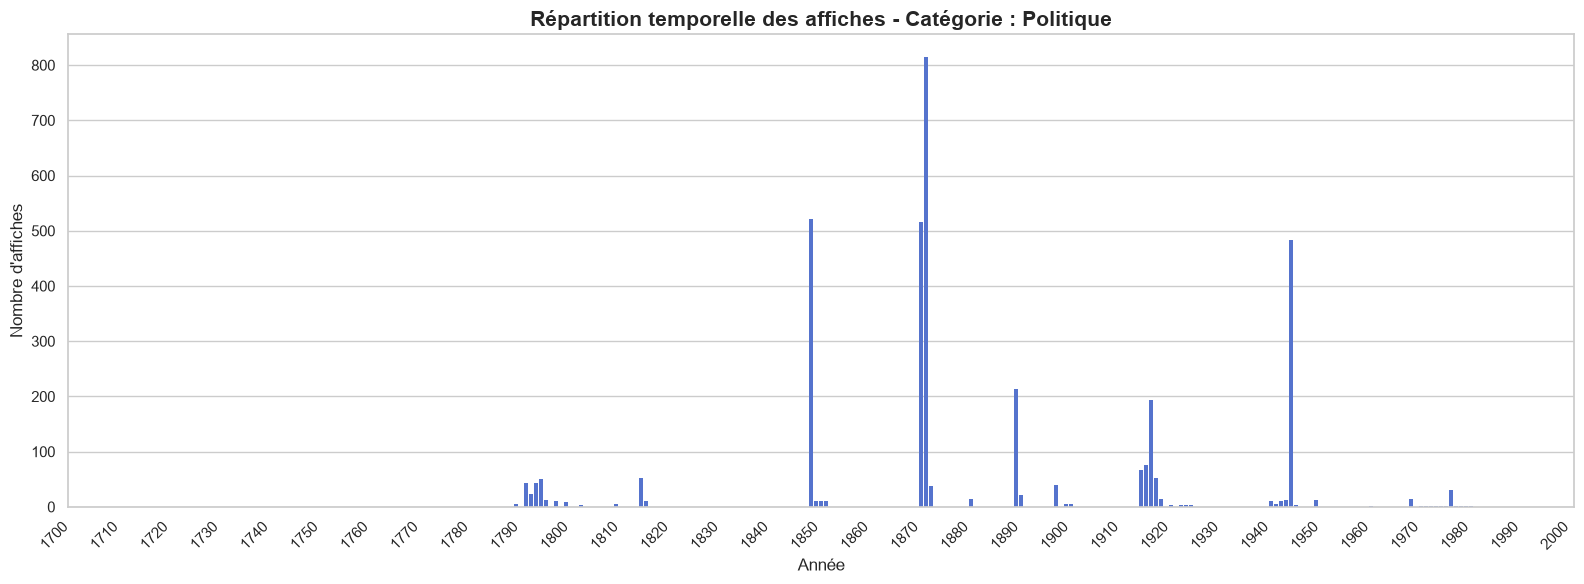

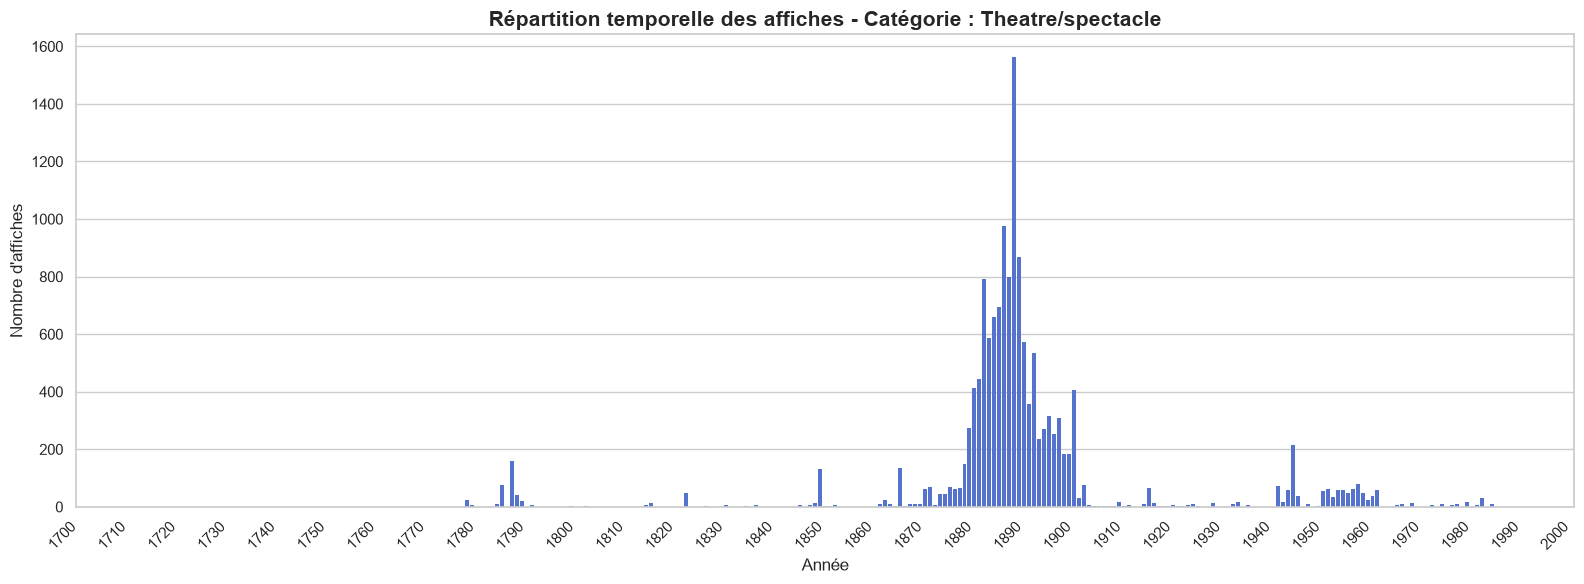

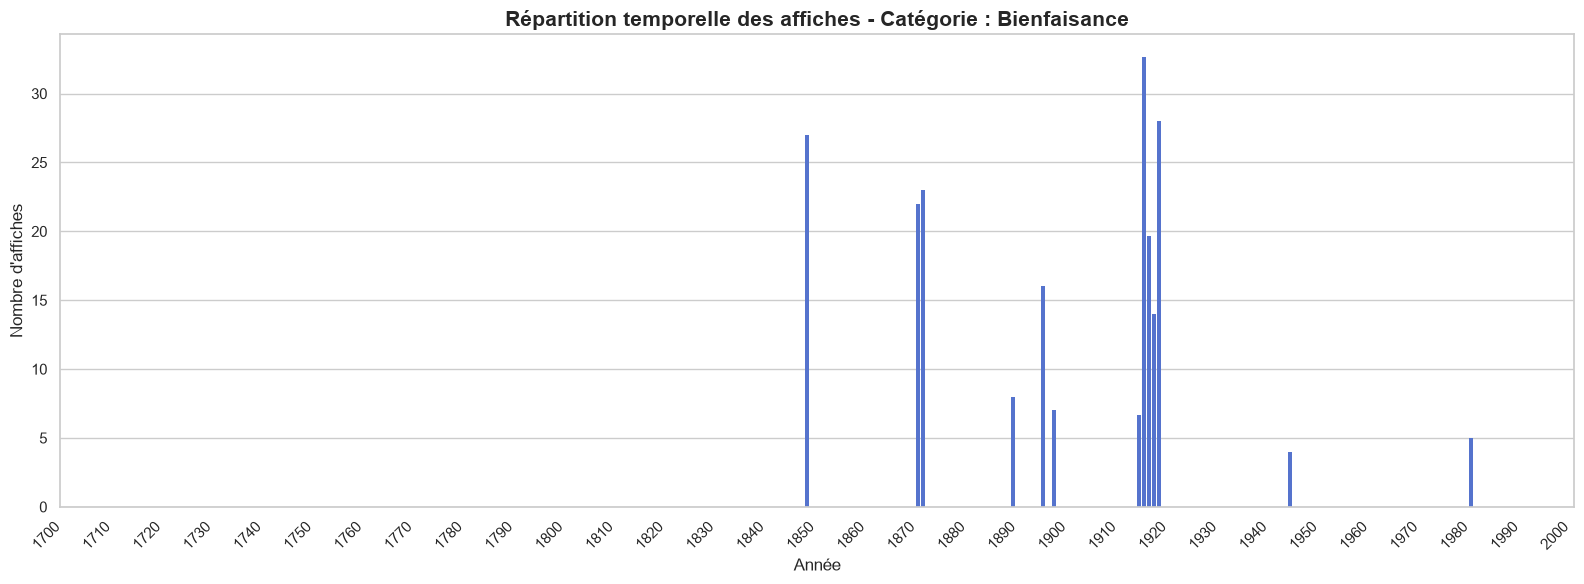

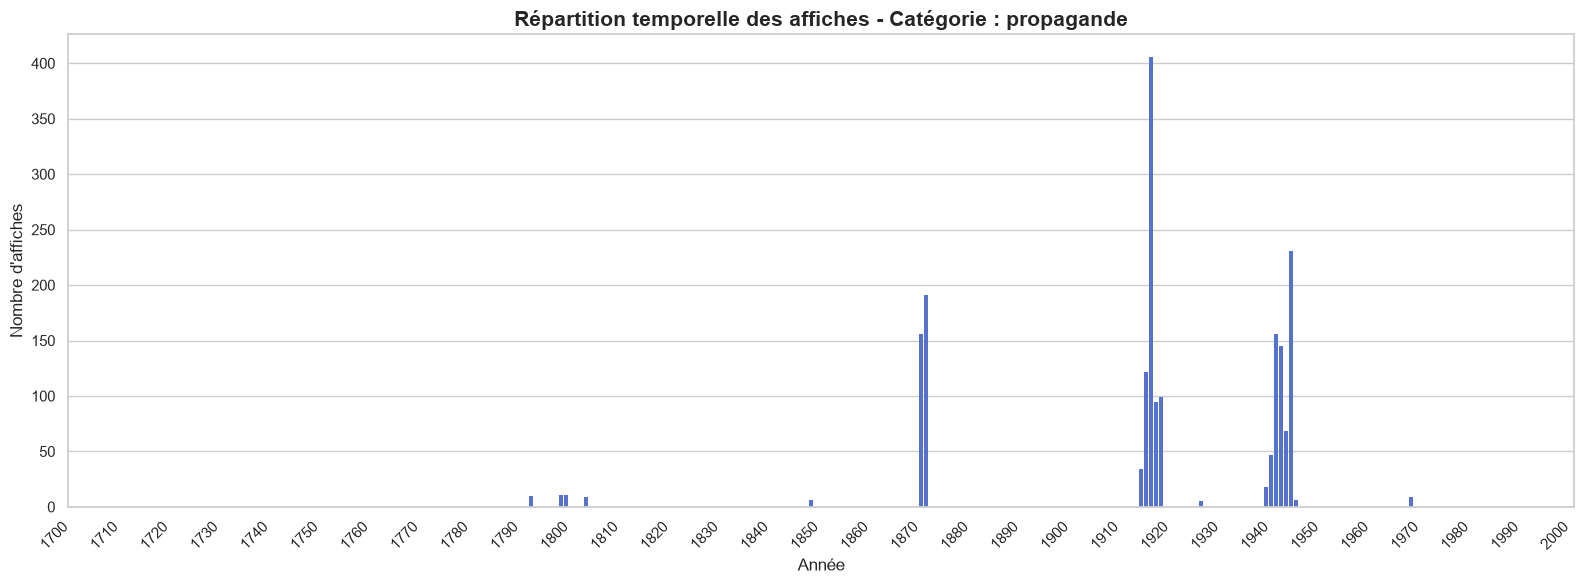

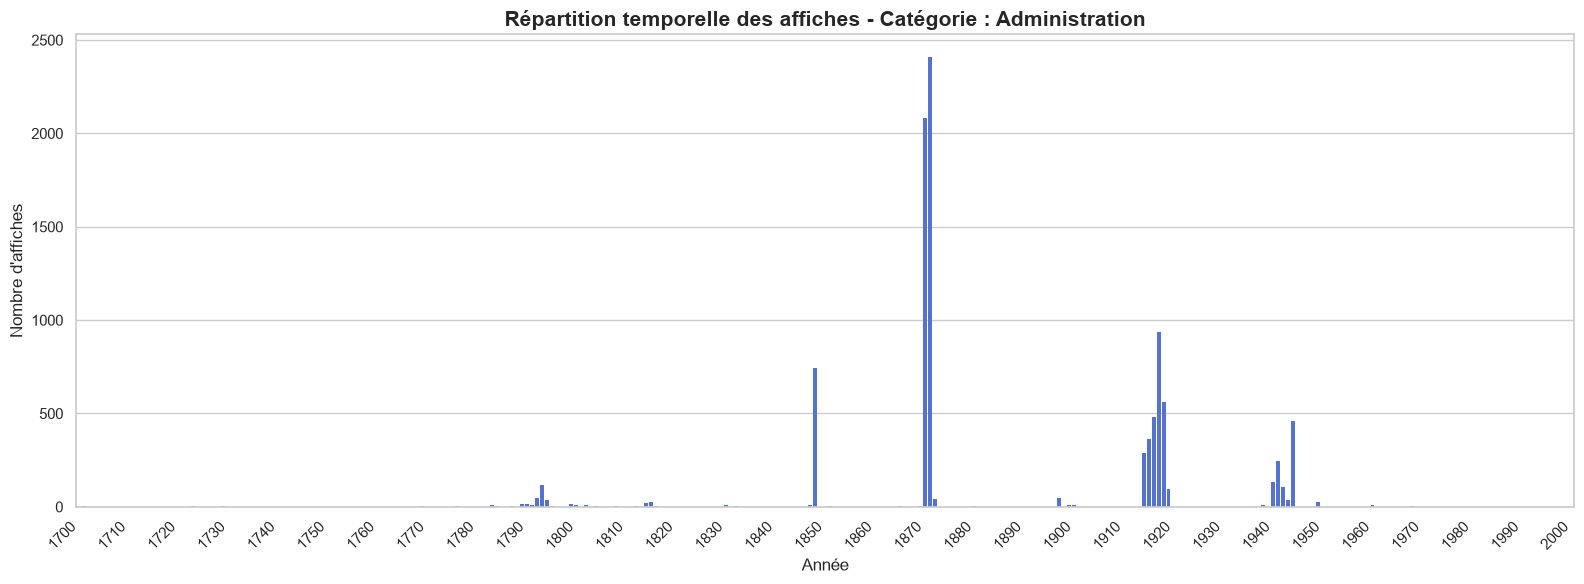

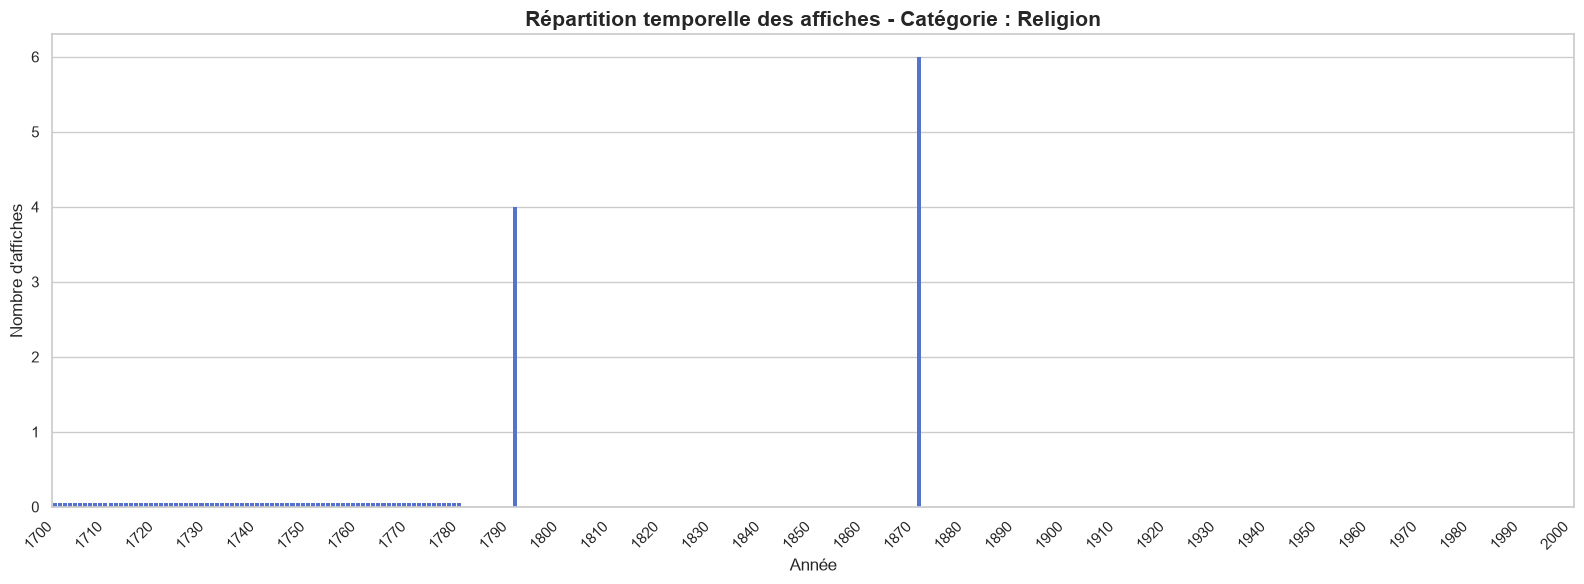

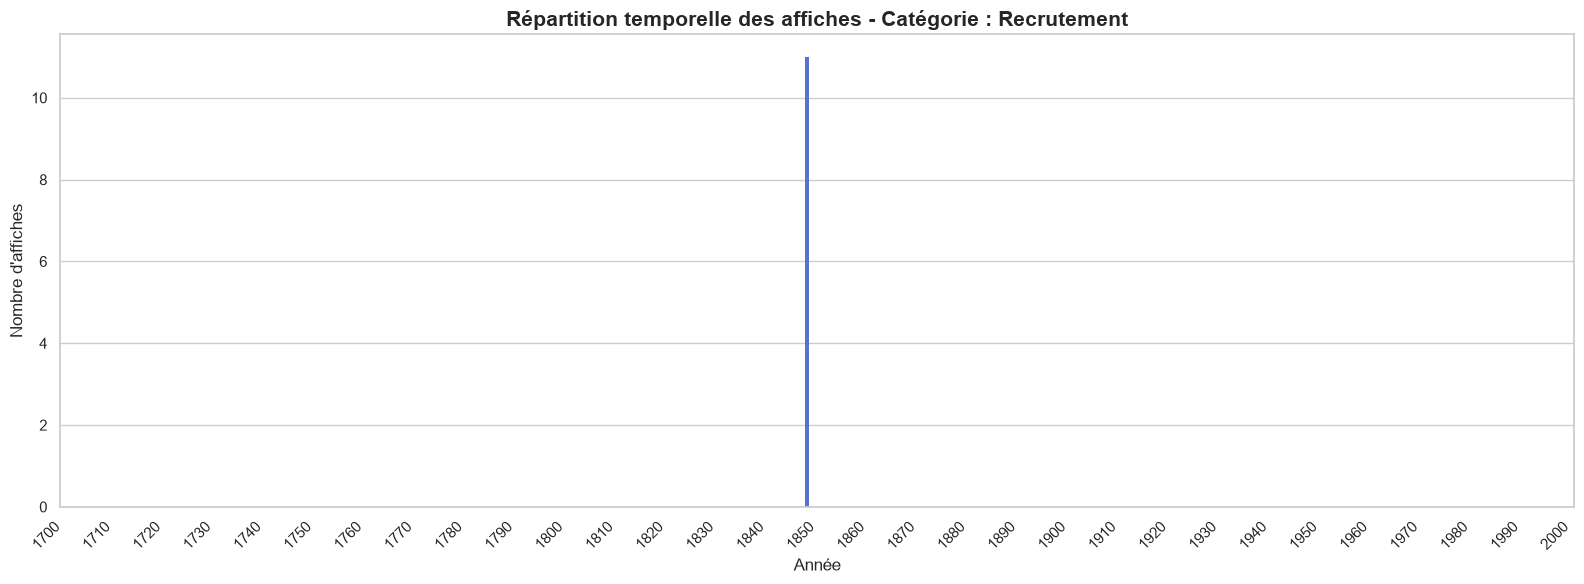

In [ ]:
# Histogramme par cumul probabiliste
annee_min = 1700
annee_max = 2000
toutes_les_annees = list(range(annee_min, annee_max + 1))
categories = df['categorie'].dropna().unique()

# ÉTAPE 1 : Calcul préalable pour déterminer la valeur MAXIMALE absolue
max_poids_global = 0.0
dict_cumul_par_cat = {}

for cat in categories:
    df_cat = df[df['categorie'] == cat]
    cumul_probabiliste = {annee: 0.0 for annee in toutes_les_annees}
    
    for idx, row in df_cat.iterrows():
        debut = row['debut']
        fin = row['fin']
        
        if pd.notna(debut) and pd.notna(fin) and fin >= debut:
            largeur_intervalle = int(fin) - int(debut) + 1
            probabilite_par_annee = 1.0 / largeur_intervalle
            
            for annee in range(int(debut), int(fin) + 1):
                if annee in cumul_probabiliste:
                    cumul_probabiliste[annee] += probabilite_par_annee
                    
    df_cumul_cat = pd.DataFrame(list(cumul_probabiliste.items()), columns=['Annee', 'Poids_Probabiliste'])
    dict_cumul_par_cat[cat] = df_cumul_cat
    
    # Mise à jour de la valeur max globale
    max_cat = df_cumul_cat['Poids_Probabiliste'].max()
    if max_cat > max_poids_global:
        max_poids_global = max_cat

# On ajoute une petite marge de 5% au-dessus de la valeur max pour la lisibilité du graphique
limite_y_max = max_poids_global * 1.05

# ÉTAPE 2 : Génération des graphiques avec la même échelle Y
for cat, df_cumul_cat in dict_cumul_par_cat.items():
    plt.figure(figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    sns.barplot(data=df_cumul_cat, x='Annee', y='Poids_Probabiliste', color='royalblue', edgecolor='none')

    # Ajustement de l'axe X
    pas_affichage = 10
    indices_affichage = [i for i, annee in enumerate(df_cumul_cat['Annee']) if annee % pas_affichage == 0]
    annees_affichage = [annee for annee in df_cumul_cat['Annee'] if annee % pas_affichage == 0]

    if annee_min not in annees_affichage:
        indices_affichage.insert(0, 0)
        annees_affichage.insert(0, annee_min)
    if annee_max not in annees_affichage:
        indices_affichage.append(len(df_cumul_cat) - 1)
        annees_affichage.append(annee_max)

    plt.xticks(
        ticks=indices_affichage, 
        labels=annees_affichage, 
        rotation=45,
        ha='right'
    )

    plt.title(f"Répartition temporelle des affiches - Catégorie : {cat}", fontsize=15, fontweight='bold')
    plt.xlabel("Année", fontsize=12)
    plt.ylabel("Nombre d'affiches", fontsize=12)

    plt.tight_layout()
    
    nom_fichier_propre = "".join(c if c.isalnum() else "_" for c in str(cat))
    plt.savefig(f"proba_categorie_{nom_fichier_propre}.png", dpi=600)
    
    plt.show()
    plt.close()

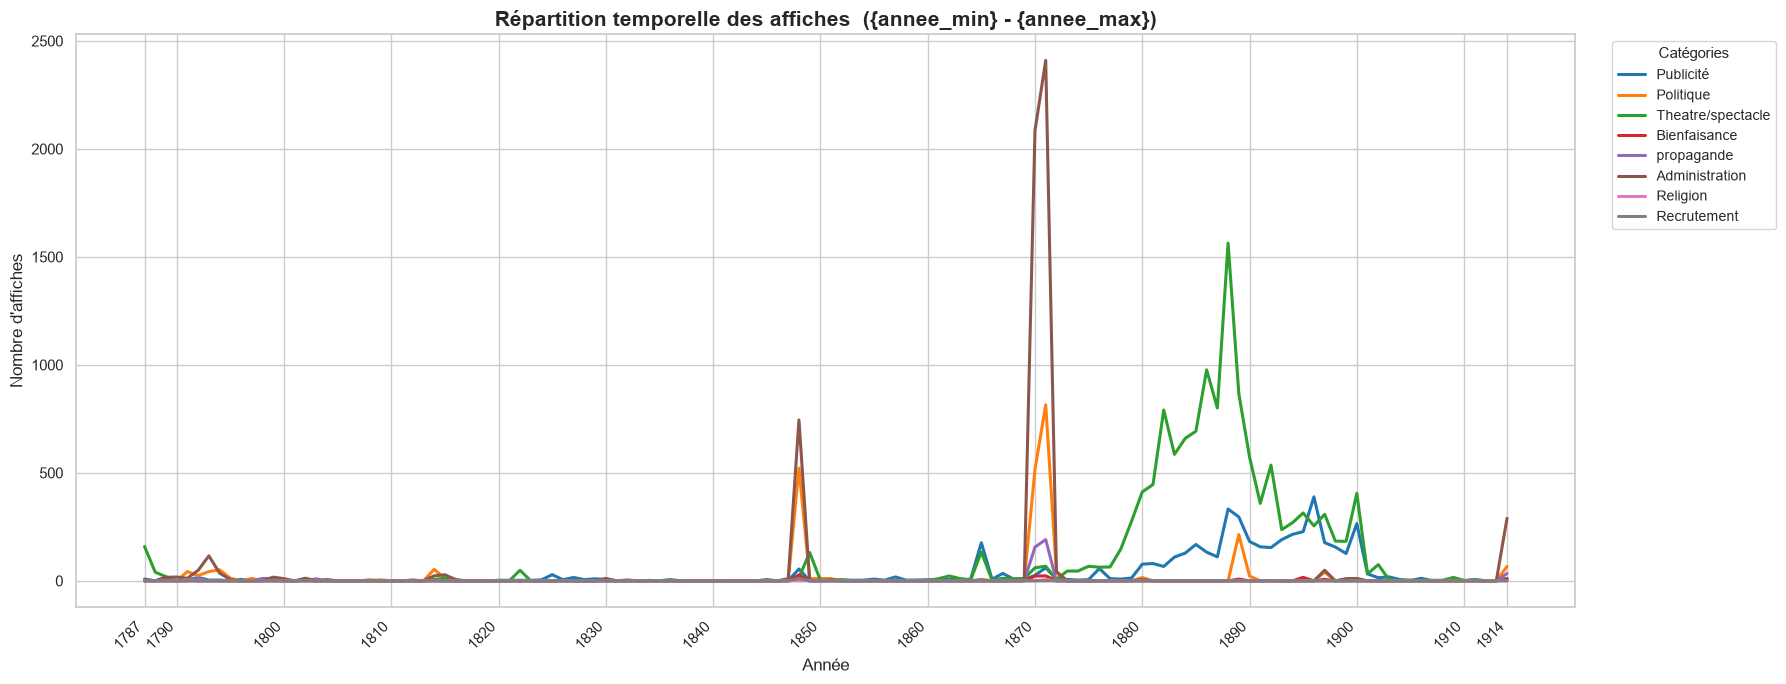

In [ ]:

# Histogramme toutes catégories

# 1. Définition des bornes temporelles
annee_min = 1787
annee_max = 1914
toutes_les_annees = list(range(annee_min, annee_max + 1))

# Récupération des catégories uniques (exclut les NaN)
categories = df['categorie'].dropna().unique()

# 2. Construction de la structure de données globale
donnees_categories = []

for cat in categories:
    df_cat = df[df['categorie'] == cat]
    cumul_probabiliste = {annee: 0.0 for annee in toutes_les_annees}
    
    for idx, row in df_cat.iterrows():
        debut = row['debut']
        fin = row['fin']
        
        if pd.notna(debut) and pd.notna(fin) and fin >= debut:
            largeur_intervalle = int(fin) - int(debut) + 1
            probabilite_par_annee = 1.0 / largeur_intervalle
            
            for annee in range(int(debut), int(fin) + 1):
                if annee in cumul_probabiliste:
                    cumul_probabiliste[annee] += probabilite_par_annee
                    
    for annee, poids in cumul_probabiliste.items():
        donnees_categories.append({
            'Annee': annee,
            'Poids_Probabiliste': poids,
            'Categorie': cat
        })

df_cumul_global = pd.DataFrame(donnees_categories)

# 3. Génération du graphique comparatif
plt.figure(figsize=(18, 7))
sns.set_theme(style="whitegrid")

# Tracé des courbes par catégorie avec des couleurs distinctes (palette 'tab10' ou 'Set2')
sns.lineplot(
    data=df_cumul_global, 
    x='Annee', 
    y='Poids_Probabiliste', 
    hue='Categorie', 
    palette='tab10', 
    linewidth=2.2
)

# 4. Ajustement dynamique de l'axe X
pas_affichage = 10
annees_affichage = [a for a in toutes_les_annees if a % pas_affichage == 0]

if annee_min not in annees_affichage:
    annees_affichage.insert(0, annee_min)
if annee_max not in annees_affichage:
    annees_affichage.append(annee_max)

plt.xticks(
    ticks=annees_affichage, 
    labels=annees_affichage, 
    rotation=45,
    ha='right'
)

# 5. Titres, axes et placement de la légende en dehors du tracé
plt.title("Répartition temporelle des affiches  ({annee_min} - {annee_max})", fontsize=15, fontweight='bold')
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'affiches", fontsize=12)

# Place la légende à droite de la figure pour ne pas masquer les courbes
plt.legend(title="Catégories", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig("proba_toutes_categories.png", dpi=600)
plt.show()
plt.close()

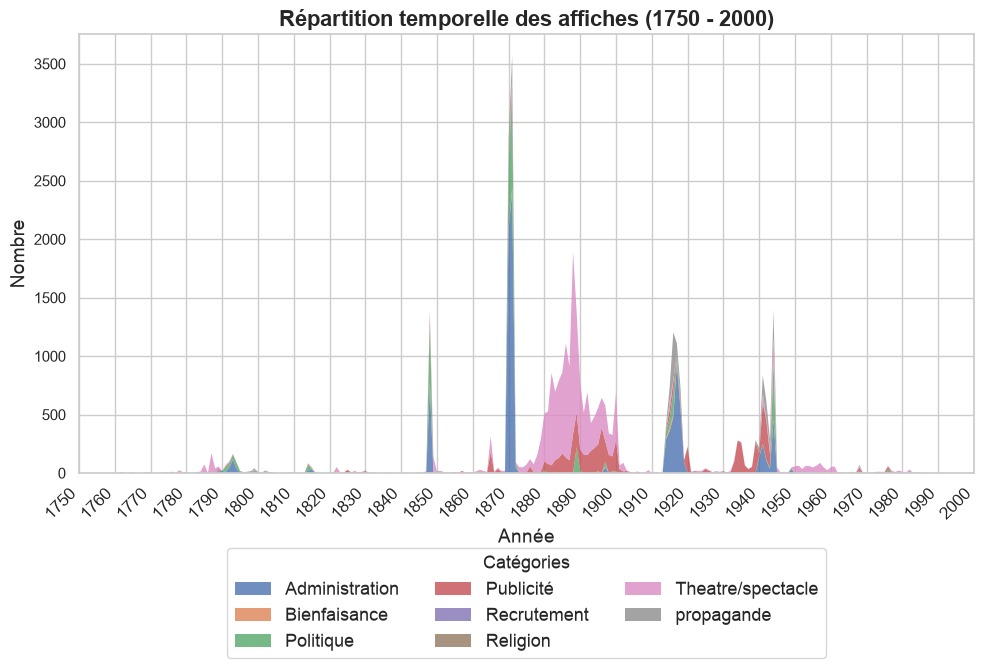

In [ ]:
# STACKED AREA CHART (AIRES EMPILÉES)
# 1. Définition des bornes temporelles
annee_min = 1750
annee_max = 2000
toutes_les_annees = list(range(annee_min, annee_max + 1))

categories = df['categorie'].dropna().unique()

# 2. Construction des données par catégorie
donnees_categories = []

for cat in categories:
    df_cat = df[df['categorie'] == cat]
    cumul_probabiliste = {annee: 0.0 for annee in toutes_les_annees}
    
    for idx, row in df_cat.iterrows():
        debut = row['debut']
        fin = row['fin']
        
        if pd.notna(debut) and pd.notna(fin) and fin >= debut:
            largeur_intervalle = int(fin) - int(debut) + 1
            probabilite_par_annee = 1.0 / largeur_intervalle
            
            for annee in range(int(debut), int(fin) + 1):
                if annee in cumul_probabiliste:
                    cumul_probabiliste[annee] += probabilite_par_annee
                    
    for annee, poids in cumul_probabiliste.items():
        donnees_categories.append({
            'Annee': annee,
            'Poids_Probabiliste': poids,
            'Categorie': cat
        })

# 3. Pivoter le DataFrame pour avoir les années en index et chaque catégorie en colonne
df_cumul_global = pd.DataFrame(donnees_categories)
df_pivot = df_cumul_global.pivot(index='Annee', columns='Categorie', values='Poids_Probabiliste').fillna(0)

# 4. Génération du Stacked Area Chart
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Tracé des aires empilées
plt.stackplot(
    df_pivot.index, 
    df_pivot.T, 
    labels=df_pivot.columns, 
    alpha=0.8,
    edgecolor='none'
)

# 5. Ajustement de l'axe X
pas_affichage = 10
annees_affichage = [a for a in toutes_les_annees if a % pas_affichage == 0]

if annee_min not in annees_affichage:
    annees_affichage.insert(0, annee_min)
if annee_max not in annees_affichage:
    annees_affichage.append(annee_max)

plt.xticks(
    ticks=annees_affichage, 
    labels=annees_affichage, 
    rotation=45,
    ha='right',
    fontsize=12
)

# Limites pour coller parfaitement aux bords des années
plt.xlim(annee_min, annee_max)

# 6. Titres, axes et légende
plt.title(f"Répartition temporelle des affiches ({annee_min} - {annee_max})", fontsize=16, fontweight='bold')
plt.xlabel("Année", fontsize=14)
plt.ylabel("Nombre", fontsize=14)

# Place la légende en dehors du tracé à droite
#plt.legend(title="Catégories", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, title_fontsize=11)
plt.legend(
    title="Catégories",
    bbox_to_anchor=(0.5, -0.15),
    loc='upper center',
    ncols=3,  # Aligne les éléments horizontalement (ou ncol=3 selon la version)
    fontsize=13,
    title_fontsize=13
)

plt.tight_layout()
plt.savefig("stacked_area_categories.png", dpi=800)
plt.show()
plt.close()

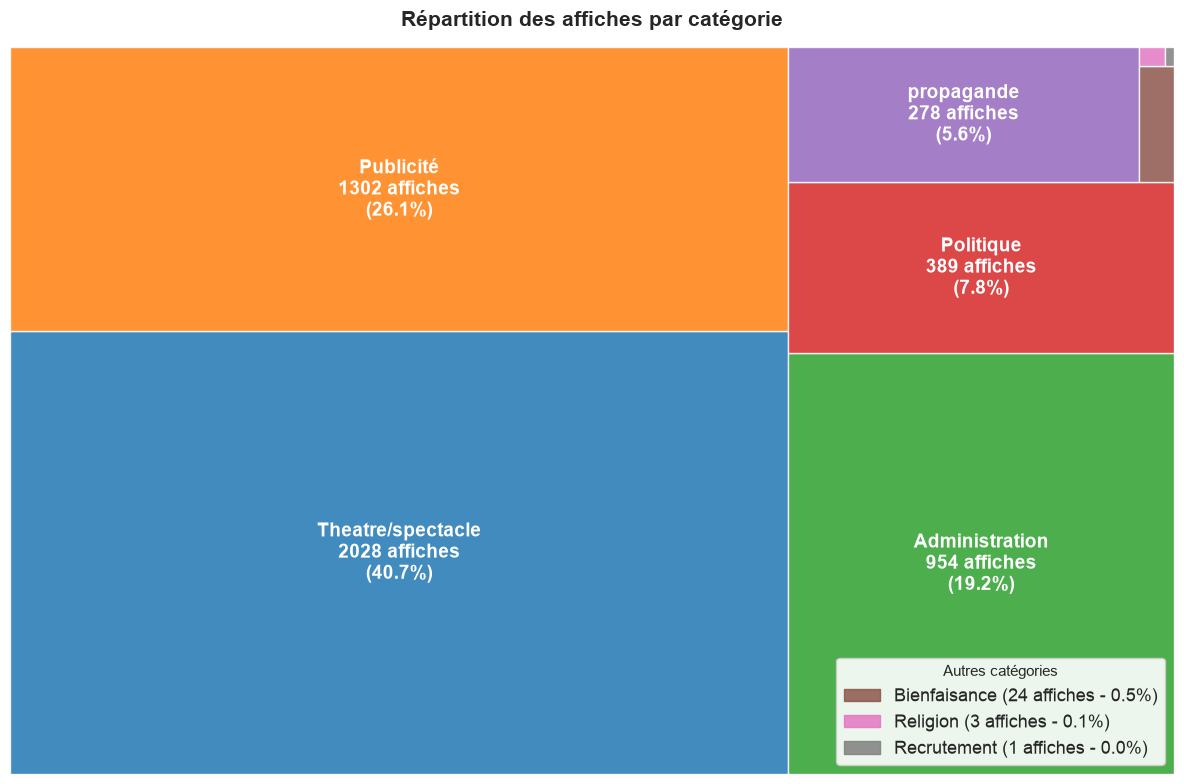

In [27]:
# 1. Calcul des effectifs par catégorie (comptage d'affiches uniques 's')
df_counts = df.groupby('categorie')['s'].nunique().reset_index()
df_counts.columns = ['Categorie', 'Nombre']
df_counts = df_counts.sort_values(by='Nombre', ascending=False).reset_index(drop=True)

total = df_counts['Nombre'].sum()

# 2. Condition sur la taille : masquer le texte si < 3% du total
seuil_affichage = 0.03  # 3%

labels = []
for _, row in df_counts.iterrows():
    proportion = row['Nombre'] / total
    if proportion >= seuil_affichage:
        labels.append(f"{row['Categorie']}\n{row['Nombre']} affiches\n({proportion:.1%})")
    else:
        labels.append("")  # Case trop petite -> pas de texte

# 3. Tracé du Treemap
plt.figure(figsize=(12, 8))
colors = sns.color_palette("tab10", len(df_counts))

squarify.plot(
    sizes=df_counts['Nombre'], 
    label=labels, 
    color=colors, 
    alpha=0.85, 
    pad=False,
    text_kwargs={'fontsize': 14, 'color': 'white', 'weight': 'bold'}
)

# 4. Légende pour les 3 plus petites catégories
petites_cats = df_counts.tail(3)

legend_handles = []
for idx, row in petites_cats.iterrows():
    proportion = row['Nombre'] / total
    libelle = f"{row['Categorie']} ({row['Nombre']} affiches - {proportion:.1%})"
    
    patch = mpatches.Patch(color=colors[idx], alpha=0.85, label=libelle)
    legend_handles.append(patch)

plt.legend(
    handles=legend_handles, 
    title="Autres catégories", 
    loc='lower right', 
    fontsize=13, 
    title_fontsize=11,
    frameon=True,
    facecolor='white',
    framealpha=0.9
)

plt.title("Répartition des affiches par catégorie", fontsize=15, fontweight='bold', pad=15)
plt.axis('off')

plt.tight_layout()
plt.savefig("repartition_treemap_filtre.png", dpi=600)
plt.show()
plt.close()

/tmp/ipykernel_288611/422751713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


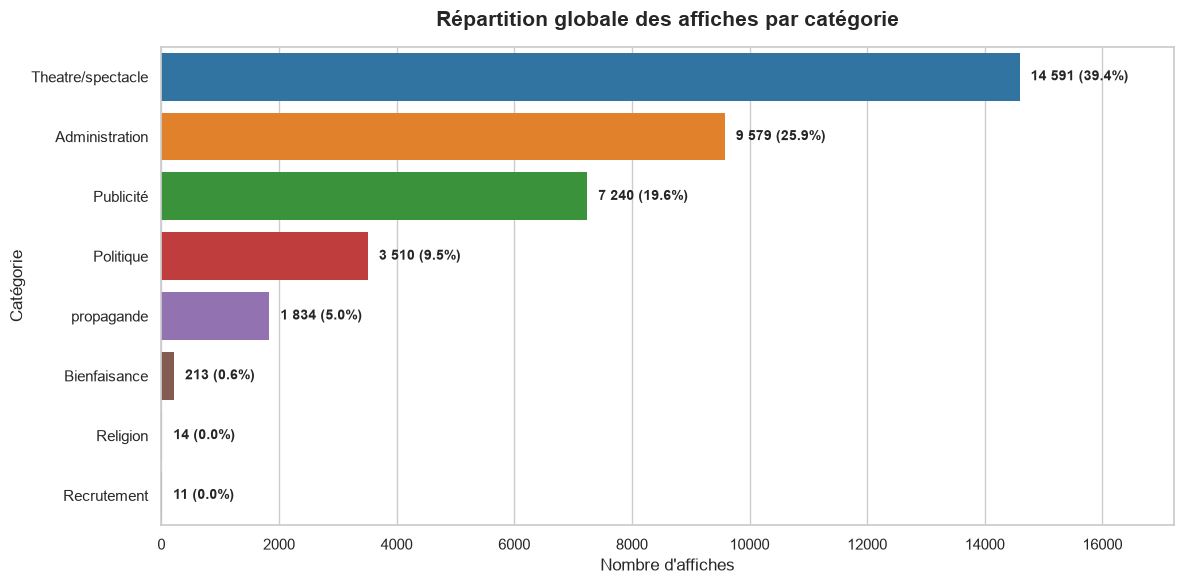

In [15]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Tracé des barres horizontales triées
ax = sns.barplot(
    data=df_counts, 
    x='Nombre', 
    y='Categorie', 
    palette="tab10", 
    edgecolor="none"
)

# Ajout des valeurs et pourcentages au bout de chaque barre
total = df_counts['Nombre'].sum()
for p in ax.patches:
    valeur = int(p.get_width())
    pourcentage = (valeur / total) * 100
    ax.annotate(
        f'{valeur:,} ({pourcentage:.1f}%)'.replace(',', ' '), 
        (p.get_width(), p.get_y() + p.get_height() / 2.), 
        ha='left', va='center', 
        xytext=(8, 0), textcoords='offset points', 
        fontsize=10, fontweight='bold'
    )

plt.title("Répartition globale des affiches par catégorie", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Nombre d'affiches", fontsize=12)
plt.ylabel("Catégorie", fontsize=12)

# Marge à droite pour éviter de couper le texte des annotations
plt.xlim(0, df_counts['Nombre'].max() * 1.18)

plt.tight_layout()
plt.savefig("repartition_bars.png", dpi=600)
plt.show()
plt.close()

In [ ]:
# 1. TOP CONTRIBUTEURS (AGENTS / COMMANDITAIRES) PAR CATÉGORIE
# Fonction de normalisation (enlève accents, majuscules et espaces superflus)
def normaliser_nom(texte):
    if not isinstance(texte, str):
        return ""
    # Décomposition NFD pour séparer les caractères des accents
    texte_clean = unicodedata.normalize('NFD', texte)
    # Suppression des diacritiques (accents)
    texte_clean = "".join(c for c in texte_clean if unicodedata.category(c) != 'Mn')
    # Passage en minuscules et suppression des espaces doubles/extrêmes
    return " ".join(texte_clean.lower().split())

top_n = 5

# 1. Filtrage des lignes valides
df_valid = df.dropna(subset=['categorie', 'nomagent']).copy()

# 2. Création d'une clé normalisée pour le regroupement
df_valid['nomagent_clean'] = df_valid['nomagent'].apply(normaliser_nom)

# 3. Création d'une carte pour garder la forme la plus propre/fréquente d'affichage
# (ex: "République Française" au lieu de "republique francaise")
nom_affichage_map = (
    df_valid.groupby(['nomagent_clean', 'nomagent'])
    .size()
    .reset_index(name='count')
    .sort_values(['nomagent_clean', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['nomagent_clean'])
    .set_index('nomagent_clean')['nomagent']
    .to_dict()
)

# 4. Groupement sur la clé normalisée
top_contributeurs = (
    df_valid.groupby(['categorie', 'nomagent_clean'])
    .size()
    .reset_index(name='nb_affiches')
    .sort_values(['categorie', 'nb_affiches'], ascending=[True, False])
)

# 5. Réassignation du nom propre d'affichage
top_contributeurs['nomagent'] = top_contributeurs['nomagent_clean'].map(nom_affichage_map)

# 6. Extraction des N premiers par catégorie
top_contributeurs_par_cat = (
    top_contributeurs[['categorie', 'nomagent', 'nb_affiches']]
    .groupby('categorie')
    .head(top_n)
)

print("=== TOP CONTRIBUTEURS PAR CATÉGORIE ===")
print(top_contributeurs_par_cat.to_string(index=False))

# Sauvegarde en CSV
top_contributeurs_par_cat.to_csv(" .csv", index=False, encoding='utf-8')

=== TOP CONTRIBUTEURS PAR CATÉGORIE ===
        categorie                             nomagent  nb_affiches
   Administration                 REPUBLIQUE FRANCAISE         3055
   Administration                 PREFECTURE DE POLICE          408
   Administration                 Imprimerie Nationale          267
   Administration                     COMMUNE DE PARIS          214
   Administration                       VILLE DE PARIS          208
     Bienfaisance                 REPUBLIQUE FRANCAISE           25
     Bienfaisance                       VILLE DE PARIS           23
     Bienfaisance                      POMMES DE TERRE            9
     Bienfaisance                     Imprimerie Chaix            7
     Bienfaisance                     ADRIEN MITHOUARD            6
        Politique                 REPUBLIQUE FRANCAISE          655
        Politique                       VILLE DE PARIS          124
        Politique                       HOTEL DE VILLE           90
        

In [ ]:
# EXTRACTION DES COMPOSANTES CONNEXES ET EXPORT HTML (IMPRIMEURS & DESSINATEURS)

print(
    "\nRecherche et enregistrement des composantes connexes en HTML par"
    " catégorie (Imprimeurs & Dessinateurs uniquement)..."
)

def normaliser_nom(texte):
    if not isinstance(texte, str):
        return ""
    texte_clean = unicodedata.normalize("NFD", texte)
    texte_clean = "".join(
        c for c in texte_clean if unicodedata.category(c) != "Mn"
    )
    texte_clean = re.sub(r"[^\w\s]", " ", texte_clean)
    return " ".join(texte_clean.lower().split())


# 1. Préparation des données valides pour le graphe
df_valid_graph = df.dropna(subset=["categorie", "nomagent", "s", "typeAgent"]).copy()
df_valid_graph["nomagent_clean"] = df_valid_graph["nomagent"].apply(normaliser_nom)

# 2. FILTRE : On ne garde QUE les imprimeurs et les dessinateurs
def est_role_cible(role):
    role_str = str(role).lower()
    mots_cles = ['imprimeur', 'lithographe', 'gravure', 'dessinateur', 'illustrateur', 'artiste', 'peintre']
    return any(keyword in role_str for keyword in mots_cles)

df_valid_graph = df_valid_graph[df_valid_graph['typeAgent'].apply(est_role_cible)].copy()

# 3. Dictionnaire pour associer chaque agent à son rôle
dict_roles = (
    df_valid_graph.set_index("nomagent_clean")["typeAgent"]
    .to_dict()
)

# Configuration du dossier d'exportation
base_output_dir = "./evaluation_carnavalet/composantes_connexes/categories"
os.makedirs(base_output_dir, exist_ok=True)
df["composante_connexe"] = None

# Namespace RDF pour la conversion
RIC = Namespace("https://www.ica.org/standards/RiC/ontology#")

# Traitement par catégorie
for cat in df_valid_graph['categorie'].unique():
    df_cat = df_valid_graph[df_valid_graph['categorie'] == cat]
    if df_cat.empty:
        continue

    cat_folder_name = "".join(c if c.isalnum() else "_" for c in str(cat))
    cat_output_dir = os.path.join(base_output_dir, cat_folder_name)
    os.makedirs(cat_output_dir, exist_ok=True)

    # 1. Construction du graphe biparti NetworkX (Affiche <-> Agent)
    G_biparti = nx.Graph()
    for _, row in df_cat.iterrows():
        affiche = row['s']
        agent_key = row['nomagent_clean']
        G_biparti.add_edge(affiche, agent_key)

    # 2. PROJECTION : Création du graphe direct des Agents (Agent <-> Agent)
    G_agents = nx.Graph()
    
    affiches_nodes = [n for n in G_biparti.nodes() if str(n).startswith("http")]
    for affiche in affiches_nodes:
        agents = list(G_biparti.neighbors(affiche))
        for a1, a2 in itertools.combinations(agents, 2):
            if G_agents.has_edge(a1, a2):
                G_agents[a1][a2]['weight'] += 1
            else:
                G_agents.add_edge(a1, a2, weight=1)

    # Inscription de l'attribut de rôle (typeAgent) sur chaque nœud du graphe d'agents
    for node in G_agents.nodes():
        role = dict_roles.get(node, "")
        G_agents.nodes[node]['typeAgent'] = role

    # -----------------------------------------------------------------
    # EXPORT DU RÉSEAU GLOBAL DE LA CATÉGORIE (AVEC NOM DE CATÉGORIE)
    if G_agents.number_of_edges() > 0:
        nom_fichier_global = f"reseau_global_{cat_folder_name}.html"
        chemin_global_cat = os.path.join(cat_output_dir, nom_fichier_global)
        
        utils.save_global_graph_html(
            graph=G_agents,
            output_filename=chemin_global_cat,
            width="100%",
            height="900px"
        )
    # -----------------------------------------------------------------

    # 3. Extraction des composantes connexes sur le graphe biparti
    composantes = sorted(nx.connected_components(G_biparti), key=len, reverse=True)

    # Compteur pour la numérotation séquentielle des fichiers HTML enregistrés
    comp_html_count = 1

    for idx, comp in enumerate(composantes, start=1):
        taille_composante = len(comp)

        # Mapping des composantes dans le df
        affiches_in_comp = {node for node in comp if str(node).startswith("http")}
        agents_keys = {node for node in comp if not str(node).startswith("http")}
        id_comp_str = f"{cat_folder_name}_comp_{idx}"
        
        mask = (df['categorie'] == cat) & (
            df['s'].isin(affiches_in_comp) | 
            df['nomagent'].apply(normaliser_nom).isin(agents_keys)
        )
        df.loc[mask, 'composante_connexe'] = id_comp_str

        # 4. Sauvegarde HTML des composantes connexes
        if taille_composante > 1:
            agents_in_comp = [node for node in comp if not str(node).startswith("http")]
            sous_graphe_agents = G_agents.subgraph(agents_in_comp)

            if sous_graphe_agents.number_of_edges() > 0:
                nom_fichier_comp = f"composante_{comp_html_count}_taille_{taille_composante}.html"
                chemin_complet_comp = os.path.join(cat_output_dir, nom_fichier_comp)

                utils.save_global_graph_html(
                    graph=sous_graphe_agents,
                    output_filename=chemin_complet_comp,
                    width="100%",
                    height="900px"
                )
                
                comp_html_count += 1


Recherche et enregistrement des composantes connexes en HTML par catégorie (Imprimeurs & Dessinateurs uniquement)...


KeyboardInterrupt: 